# Finance Lakehouse with PySpark

This notebook demonstrates a simplified financial lakehouse implemented locally using historical market data from Yahoo Finance. The pipeline follows a modern medallion architecture:


| Layer      | Tool                | Purpose                                                                               |
| ---------- | ------------------- | ---------------------------------------------------------------------------------- |
| **Raw**    | `yfinance` + Pandas | Download and store source data exactly as received.                                |
| **Bronze** | Pandas + PyArrow    | Simple CSV → Parquet conversion. Spark would be overkill for 10 CSV files.         |
| **Silver** | **PySpark**         | Read the Bronze lake, clean, validate, standardize, and write the trusted dataset. |
| **Gold**   | **PySpark**         | Compute features and create analytics-ready datasets.                              |
| **ML**     | **Spark MLlib**     | Train and evaluate models on the Gold dataset.                                     |


**Implementation Notes**  
This pipeline is configured to dynamically fetch 10 years of historical data based on the date on which it is run.  As a result, each daily execution writes a different dataset to the lakehouse and experimental results change as newer observations become available.

The results presented in the accompanying report therefore will not necessarily match the results produced by subsequent runs of this notebook.  This behavior is intentional and is designed to demonstrate how the pipeline could operate in a real-time decision-support environment where models are periodically evaluated using the most current available data.

Another intentional design decision is to overwrite the entire lakehouse with each run.  This approach limits the amount of data accumulated for the purposes of this project and keeps the implementation within the intended scope.  In a practical production environment, new observations could instead be appended to existing records using appropriate strategies for managing data quality, duplication, historical retention and pipeline reliability.

---

# Environment Setup

## Imports

In [1]:
# standard libraries
from pathlib import Path
from datetime import date, datetime, UTC
from dateutil.relativedelta import relativedelta
import builtins
import shutil

# data & visualization
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# PySpark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window

# PySpark ML
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder

## Configuration

In [2]:
SEED=42

### Lakehouse Directories

In [3]:
# setting project root
PROJECT_ROOT = Path.cwd()

# defining directories for each lakehouse layer
RAW_DIR = PROJECT_ROOT / "data" / "raw"
BRONZE_DIR = PROJECT_ROOT / "data" / "bronze"
SILVER_DIR = PROJECT_ROOT / "data" / "silver"
GOLD_DIR = PROJECT_ROOT / "data" / "gold"

# defining directory for output figures
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / OUTPUT_DIR / "figures"
SUMMARY_DIR = PROJECT_ROOT / OUTPUT_DIR / "summaries"
MODELING_DIR = PROJECT_ROOT / OUTPUT_DIR / "modeling"

In [4]:
# creating lakehouse directories
for directory in [RAW_DIR, BRONZE_DIR, SILVER_DIR, GOLD_DIR, OUTPUT_DIR, FIG_DIR, SUMMARY_DIR, MODELING_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Lakehouse directory structure created.")

# returning lakehouse folder structure
for directory in [RAW_DIR, BRONZE_DIR, SILVER_DIR, GOLD_DIR]:
    print(directory.relative_to(PROJECT_ROOT))

print(FIG_DIR.relative_to(PROJECT_ROOT))

Lakehouse directory structure created.
data/raw
data/bronze
data/silver
data/gold
outputs/figures


### Stock Tickers and Historical Time Period

Stock tickers are defined and a rolling 10-year historical period is used based on the current date.  This simulates the data requirements of a decision-support tool retreiving 10 years of market history to use in a current analysis or recommendation.

In [5]:
# defining tickers by sector/industry
TICKERS = [
    # technology
    "NVDA",
    "AAPL",
    "MSFT",
    "AVGO",
    "ORCL",

    # financials
    "JPM",
    "BRK-B",
    "BAC",

    # communication 
    "GOOGL",
    "META",

    # consumer 
    "AMZN",
    "TSLA",

    # health care
    "LLY",
    "JNJ",

    # industrials
    "CAT",
    "GE",

    # consumer staples
    "WMT",
    "PG",

    # energy
    "XOM",

    # utilities
    "NEE"
]

# defining relative history
START_DATE = (date.today() - relativedelta(years=20)).strftime("%Y-%m-%d")
END_DATE = date.today().strftime("%Y-%m-%d")

# calculating dataset scope
time_period_years = (
    pd.to_datetime(END_DATE) - pd.to_datetime(START_DATE)
).days / 365.25

print(f"Number of Tickers: {len(TICKERS)}")
print(f"Start Date (Today): {START_DATE}")
print(f"Historical Time Period: {time_period_years:.1f} years")

Number of Tickers: 20
Start Date (Today): 2006-09-04
Historical Time Period: 20.0 years


### Reset Storage Helper

This function removes and recreates a lakehouse layer and was used during development and testing.

In [6]:
def reset_storage(layer_dir):
    """
    Remove and recreate a lakehouse layer.
    Useful for rebuilding pipeline stages during development.
    """

    if layer_dir.exists():
        shutil.rmtree(layer_dir)

    layer_dir.mkdir(parents=True, exist_ok=True)

    print(f"Reset complete: {layer_dir}")

## Create Spark Session

Initializing a Spark session for processing the partitioned Bronze data and configuring Spark to display only warnings and errors during execution

In [7]:
spark = (
    SparkSession.builder
    .appName("Financial Lakehouse")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/04 14:55:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/04 14:55:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


4.1.2


---

# Data Ingestion

Historical market data is retrieved from Yahoo Finance for the configured stock list and stored as raw CSV snapshots in `data/raw/`.  The raw layer preserves the source data in its original structure while adding ingestion metadata for downstream Lakehouse processing.

## Download Ticker Data

This function is used to download historical data for single ticker and save the source snapshot to the raw data layer.

In [8]:
def download_ticker_to_csv(ticker: str) -> Path:
    """
    Download historical market data for a ticker and save the latest
    source snapshot to the raw zone.
    Returns the saved file path.
    """

    print(f"Downloading {ticker}...")

    df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False
    )

    # Flatten yfinance MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Convert index to a normal column
    df = df.reset_index()

    # Add metadata
    df["ticker"] = ticker
    df["download_timestamp"] = datetime.now(UTC)

    output_file = RAW_DIR / f"{ticker}.csv"

    df.to_csv(output_file, index=False)

    print(f"Saved: {output_file.name} ({len(df):,} rows)")

    return output_file

In [9]:
# downloading configured tickers into the raw data layer
raw_files = []

for ticker in TICKERS:
    file_path = download_ticker_to_csv(ticker)
    raw_files.append(file_path)

    file_size_mb = file_path.stat().st_size / 1_048_576
    print(f"  {ticker}: {file_size_mb:.2f} MB")

print(f"\nRaw ingestion complete: {len(raw_files)} files created.")

Saved: NVDA.csv (5,031 rows)
  NVDA: 0.73 MB
Saved: AAPL.csv (5,031 rows)
  AAPL: 0.71 MB
Saved: MSFT.csv (5,031 rows)
  MSFT: 0.71 MB
Saved: AVGO.csv (4,296 rows)
  AVGO: 0.61 MB
Saved: ORCL.csv (5,031 rows)
  ORCL: 0.70 MB
Saved: JPM.csv (5,031 rows)
  JPM: 0.70 MB
Saved: BRK-B.csv (5,031 rows)
  BRK-B: 0.69 MB
Saved: BAC.csv (5,031 rows)
  BAC: 0.70 MB
Saved: GOOGL.csv (5,031 rows)
  GOOGL: 0.72 MB
Saved: META.csv (3,594 rows)
  META: 0.50 MB
Saved: AMZN.csv (5,031 rows)
  AMZN: 0.71 MB
Saved: TSLA.csv (4,071 rows)
  TSLA: 0.58 MB
Saved: LLY.csv (5,031 rows)
  LLY: 0.69 MB
Saved: JNJ.csv (5,031 rows)
  JNJ: 0.69 MB
Saved: CAT.csv (5,031 rows)
  CAT: 0.69 MB
Saved: GE.csv (5,031 rows)
  GE: 0.70 MB
Saved: WMT.csv (5,031 rows)
  WMT: 0.71 MB
Saved: PG.csv (5,031 rows)
  PG: 0.69 MB
Saved: XOM.csv (5,031 rows)
  XOM: 0.69 MB
Saved: NEE.csv (5,031 rows)
  NEE: 0.69 MB

Raw ingestion complete: 20 files created.


## Inspect Single Raw File

In [10]:
# inspect single file
sample_raw = pd.read_csv(raw_files[0])

print(f"Shape: {sample_raw.shape}")
print(f"Columns: {sample_raw.columns.tolist()}")

sample_raw.head()

Shape: (5031, 9)
Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']


,Date,Adj Close,Close,High,Low,Open,Volume,ticker,download_timestamp
0,2006-09-05,0.434966,0.475000,0.476833,0.459500,0.466333,549354000,NVDA,2026-09-04 18:55:30.047632+00:00
1,2006-09-06,0.413141,0.451167,0.467333,0.450000,0.466667,493572000,NVDA,2026-09-04 18:55:30.047632+00:00
2,2006-09-07,0.421383,0.460167,0.470333,0.439000,0.443833,742836000,NVDA,2026-09-04 18:55:30.047632+00:00
3,2006-09-08,0.422757,0.461667,0.469500,0.451500,0.467500,447978000,NVDA,2026-09-04 18:55:30.047632+00:00
4,2006-09-11,0.429319,0.468833,0.474167,0.446167,0.451333,598266000,NVDA,2026-09-04 18:55:30.047632+00:00


---

# Bronze Layer

The Bronze layer converts the raw CSV snapshots into Parquet format and preserves the underlying market observations and ingestion metadata needed for downstream processing.  The data is organized into partitions by ticker, year and month.  This design creates a scalable storage structure that allows downstream queries and processing to target specific time periods rather than scanning the entire dataset.

The Bronze transformation follows this structure:

**CSV to Partitioned Parquet**

```text
data/
├── raw/
│   ├── AAPL.csv
│   ├── MSFT.csv
│   └── ...
│
└── bronze/
    ├── ticker=AAPL/
    │   ├── year=2016/
    │   │   ├── month=01/
    │   │   │   └── data.parquet
    │   │   ├── month=02/
    │   │   │   └── data.parquet
    │   │   └── ...
    │   └── ...
    │
    ├── ticker=MSFT/
    │   └── ...
    │
    └── ...
```

## Create Parquet Files

This function converts each raw CSV snapshot into partitioned Parquet format.  

In [11]:
def csv_to_bronze_parquet(csv_file: Path):
    df = pd.read_csv(csv_file)

    # converting date to datetime for partitioning and downstream processing
    df["Date"] = pd.to_datetime(df["Date"])

    # creating partition columns
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month.astype(str).str.zfill(2)

    ticker = df["ticker"].iloc[0]

    # writing each year/month partition as a separate parquet file
    for (year, month), partition_df in df.groupby(["year", "month"]):

        # organizing Bronze directory
        partition_path = (
            BRONZE_DIR
            / f"ticker={ticker}"
            / f"year={year}"
            / f"month={month}"
        )

        partition_path.mkdir(
            parents=True,
            exist_ok=True
        )

        output_file = partition_path / "data.parquet"
        
        # dropping columns used to organize directory structure
        (
            partition_df
            .drop(columns=["ticker", "year", "month"])
            .to_parquet(
                output_file,
                index=False,
                engine="pyarrow"
            )
        )

    return ticker, len(df)

In [12]:
for csv_file in RAW_DIR.glob("*.csv"):
    df = pd.read_csv(csv_file)

    print(f"\n{csv_file.name}")
    print(df.columns.tolist())
    print(f"Rows: {len(df):,}")


BAC.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

LLY.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

ORCL.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

PG.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

CAT.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

AMZN.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

NEE.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

MSFT.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ticker', 'download_timestamp']
Rows: 5,031

NVDA.csv
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open'

Writing parquet files.

In [13]:
# converting raw CSV files to partitioned Bronze parquet
bronze_results = []

for csv_file in RAW_DIR.glob("*.csv"):
    ticker, rows = csv_to_bronze_parquet(csv_file)
    bronze_results.append({
        "ticker": ticker,
        "rows": rows
    })

bronze_summary = pd.DataFrame(bronze_results)
bronze_summary.to_csv(
    SUMMARY_DIR / "bronze_summary.csv",
    index=False
)
print("Bronze layer created.")
bronze_summary

Bronze layer created.


,ticker,rows
0,BAC,5031
1,LLY,5031
2,ORCL,5031
3,PG,5031
4,CAT,5031
5,AMZN,5031
6,NEE,5031
7,MSFT,5031
8,NVDA,5031
9,XOM,5031


## Validate Partition Structure

The Bronze layer contains 4,600 monthly Parquet partitions organized by ticker, year and month.

In [14]:
bronze_paths = sorted(BRONZE_DIR.rglob("data.parquet"))

print(f"Total Bronze partitions: {len(bronze_paths):,}\n")
print("Example partition paths:")

for path in bronze_paths[:12]:
    print(path.relative_to(PROJECT_ROOT))

if len(bronze_paths) > 12:
    print("...")

Total Bronze partitions: 4,672

Example partition paths:
data/bronze/ticker=AAPL/year=2006/month=09/data.parquet
data/bronze/ticker=AAPL/year=2006/month=10/data.parquet
data/bronze/ticker=AAPL/year=2006/month=11/data.parquet
data/bronze/ticker=AAPL/year=2006/month=12/data.parquet
data/bronze/ticker=AAPL/year=2007/month=01/data.parquet
data/bronze/ticker=AAPL/year=2007/month=02/data.parquet
data/bronze/ticker=AAPL/year=2007/month=03/data.parquet
data/bronze/ticker=AAPL/year=2007/month=04/data.parquet
data/bronze/ticker=AAPL/year=2007/month=05/data.parquet
data/bronze/ticker=AAPL/year=2007/month=06/data.parquet
data/bronze/ticker=AAPL/year=2007/month=07/data.parquet
data/bronze/ticker=AAPL/year=2007/month=08/data.parquet
...


## Inspect Single Bronze Partition

Verifying that a single Bronze partition Parquet file can be accessed and that the stored records retain the expected structure after conversion from the raw CSV.

In [15]:
# reading a single Bronze partition
example_partition = bronze_paths[0]

bronze_df = pd.read_parquet(example_partition)

print(f"Partition: {example_partition.relative_to(PROJECT_ROOT)}")
print(bronze_df.shape)

bronze_df.head()

Partition: data/bronze/ticker=AAPL/year=2006/month=09/data.parquet
(19, 8)


,Date,Adj Close,Close,High,Low,Open,Volume,download_timestamp
0,2006-09-05,2.137940,2.552857,2.553571,2.448214,2.463214,1012457600,2026-09-04 18:55:30.348115+00:00
1,2006-09-06,2.094571,2.501071,2.560357,2.489286,2.538571,974103200,2026-09-04 18:55:30.348115+00:00
2,2006-09-07,2.177421,2.600000,2.624286,2.508929,2.521429,1267957600,2026-09-04 18:55:30.348115+00:00
3,2006-09-08,2.169047,2.590000,2.627500,2.568214,2.620357,895921600,2026-09-04 18:55:30.348115+00:00
4,2006-09-11,2.168448,2.589286,2.633214,2.550714,2.586786,949124400,2026-09-04 18:55:30.348115+00:00


---

# Silver

The Silver layer reads the partitioned Bronze Parquet data into Spark and applies data-quality checks, duplicate removal and schema standardization to create a clean analytical dataset.  The underlying market observations are retained while data types and structural conventions are standardized for consistent downstream processing.


The transformation from Bronze to Silver follows this structure:

```
data/
├── bronze/
│   ├── ticker=AAPL/
│   │   └── year=2015/
│   │       └── month=01/
│   │           └── data.parquet
│   └── ...
│
└── silver/
    ├── ticker=AAPL/
    │   └── part-*.parquet
    ├── ticker=MSFT/
    │   └── part-*.parquet
    └── ...
```

## Read & Validate Bronze Layer

Reading the partitioned Bronze Parquet dataset into Spark and validating the row count, column structure, schema and sample records before applying Silver transformations.

In [16]:
bronze_df = spark.read.parquet(str(BRONZE_DIR))

print(f"Rows: {bronze_df.count():,}")
print(f"Columns: {len(bronze_df.columns)}")

bronze_df.printSchema()

bronze_df.show(5, truncate=False, vertical=True)

Rows: 97,488
Columns: 11
root
 |-- Date: timestamp_ntz (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- download_timestamp: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)

-RECORD 0----------------------------------------------
 Date               | 2008-10-01 00:00:00              
 Adj Close          | 0.2383154183626175               
 Close              | 0.2602500021457672               
 High               | 0.2685000002384186               
 Low                | 0.2554999887943268               
 Open               | 0.2637499868869781               
 Volume             | 557208000                        
 download_timestamp | 2026-09-04 18:55:30.047632+00:00 
 ticker             | NVDA            

## Check for missing values

Checking the Bronze dataset for null values across all columns to identify potential data-quality issues before Silver transformations are applied.

In [17]:
nulls = bronze_df.select([
    F.sum(
        F.when(F.col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in bronze_df.columns
])

nulls.show(vertical=True)

[Stage 5:==============================================>       (126 + 14) / 146]

-RECORD 0-----------------
 Date               | 0   
 Adj Close          | 0   
 Close              | 0   
 High               | 0   
 Low                | 0   
 Open               | 0   
 Volume             | 0   
 download_timestamp | 0   
 ticker             | 0   
 year               | 0   
 month              | 0   



## Remove Duplicates

Removing duplicate records from the Bronze dataset to create a cleaned Silver DataFrame for downstream processing.

In [18]:
silver_df = bronze_df.dropDuplicates()

## Standardize Silver Schema

Standardizing the Silver dataset by selecting the required columns, converting the trading date to a date type and explicitly assigning appropriate numeric data types to price and volume fields.

In [19]:
# defining Silver layer schema
silver_df = bronze_df.select(
    F.to_date(F.col("Date")).alias("Date"),
    F.col("Adj Close").cast("double"),
    F.col("Open").cast("double"),
    F.col("High").cast("double"),
    F.col("Low").cast("double"),
    F.col("Close").cast("double"),
    F.col("Volume").cast("long"),
    F.col("download_timestamp"),
    F.col("ticker"),
    F.col("year"),
    F.col("month")
)

## Data Quality Rules

Rules define basic validity constraints for daily market data and are applied to identify records that violate expected relationships among price and volume fields.

In [20]:
def check_data_quality(df):
    rules = {
        "Closing Price > 0": F.col("Close") > 0,
        "Volume >= 0": F.col("Volume") >= 0,
        "High >= Low": F.col("High") >= F.col("Low")
    }

    results = []

    for rule_name, condition in rules.items():
        violations = df.filter(~condition).count()

        results.append({
            "rule": rule_name,
            "violations": violations
        })

    return pd.DataFrame(results)

In [21]:
# checking Silver data quality
quality_results = check_data_quality(silver_df)

quality_results.to_csv(
    SUMMARY_DIR / "silver_quality_results.csv",
    index=False
)

quality_results

,rule,violations
0,Closing Price > 0,0
1,Volume >= 0,0
2,High >= Low,0


## Validate Silver Dataset

In [22]:
silver_df.select(
    F.countDistinct("ticker").alias("Number of Tickers"),
    F.min("Date").alias("Start Date"),
    F.max("Date").alias("End Date")
).show()


print(f"Silver Row Count         : {silver_df.count():,}")
print(f"Silver Column Count      : {len(silver_df.columns)}\n")

silver_df.groupBy("ticker").count().orderBy("ticker").show()

silver_df.printSchema()

+-----------------+----------+----------+
|Number of Tickers|Start Date|  End Date|
+-----------------+----------+----------+
|               20|2006-09-05|2026-09-03|
+-----------------+----------+----------+

Silver Row Count         : 97,488
Silver Column Count      : 11

+------+-----+
|ticker|count|
+------+-----+
|  AAPL| 5031|
|  AMZN| 5031|
|  AVGO| 4296|
|   BAC| 5031|
| BRK-B| 5031|
|   CAT| 5031|
|    GE| 5031|
| GOOGL| 5031|
|   JNJ| 5031|
|   JPM| 5031|
|   LLY| 5031|
|  META| 3594|
|  MSFT| 5031|
|   NEE| 5031|
|  NVDA| 5031|
|  ORCL| 5031|
|    PG| 5031|
|  TSLA| 4071|
|   WMT| 5031|
|   XOM| 5031|
+------+-----+

root
 |-- Date: date (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- download_timestamp: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- year: inte

## Write Silver Dataset

Writing the cleaned Silver dataset to Parquet, partitioned by ticker and limiting the number of output files to improve storage and processing efficiency.

In [23]:
# limit output partitions for performance
silver_df = silver_df.coalesce(10)
(
    silver_df
    .write
    .mode("overwrite")
    .partitionBy("ticker")
    .parquet(str(SILVER_DIR))
)
print("Silver layer written successfully.")

[Stage 29:>                                                       (0 + 10) / 10]

Silver layer written successfully.


## Data Exploration

### Daily Returns Distriubtion

This distribution shows the frequency and spread of daily percentage changes in adjusted closing prices across the securities in the dataset.

In [24]:
# using the same 3 securities throughout
selected_tickers = ["JPM", "BRK-B", "BAC"]


# filtering Silver data to selected securities
exploration_df = (
    silver_df
    .filter(F.col("ticker").isin(selected_tickers))
    .select("Date", "Close", "Adj Close", "Volume","ticker")
    .orderBy("ticker", "Date")
)

# converting only the selected data to pandas for visualization
exploration_pd = exploration_df.toPandas()

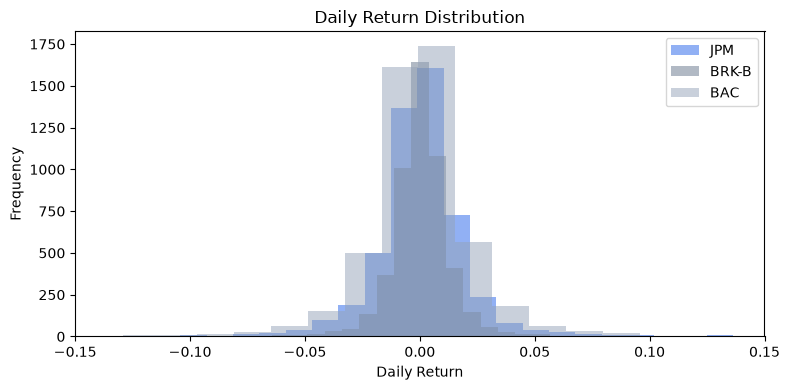

In [25]:
# defining common color scheme
colors = ["#2563EB", "#64748B", "#94A3B8"]

plt.figure(figsize=(8, 4))

for ticker, color in zip(selected_tickers, colors):
    returns = (
        exploration_pd.loc[
            exploration_pd["ticker"] == ticker, "Close"
        ]
        .pct_change()
        .dropna()
    )

    plt.hist(
        returns,
        bins=40,
        alpha=0.5,
        label=ticker,
        color=color
    )

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim(-0.15, 0.15)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "daily_return_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Normalized Adjusted Closing Price over Time

This visualization compares relative price performance across securities by normalizing adjusted closing prices to a common starting point.

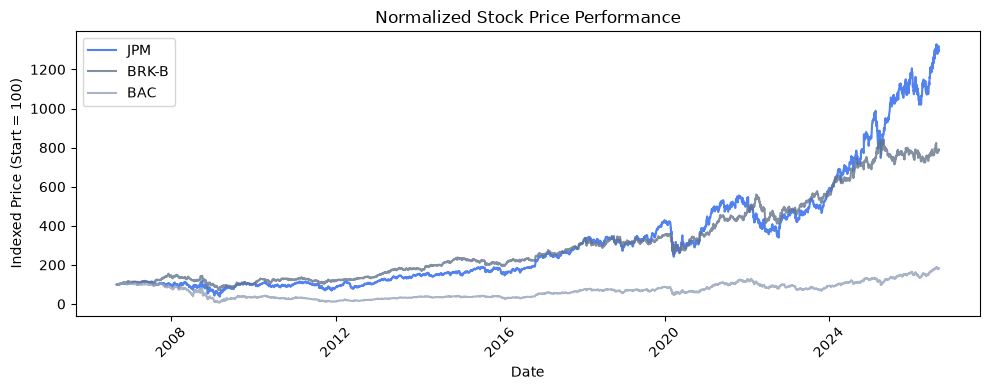

In [26]:
plt.figure(figsize=(10, 4))

for ticker, color in zip(selected_tickers, colors):
    stock = (
        exploration_pd[
            exploration_pd["ticker"] == ticker
        ]
        .sort_values("Date")
    )

    normalized = stock["Adj Close"] / stock["Adj Close"].iloc[0] * 100

    plt.plot(
        stock["Date"],
        normalized,
        label=ticker,
        alpha=0.8,
        color=color
    )

plt.title("Normalized Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "normalized_stock_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Trading Volume over Time (Log Scale)

This visualization shows trading volume over time across the securities using a logarithmic scale to make differences in trading activity easier to compare.

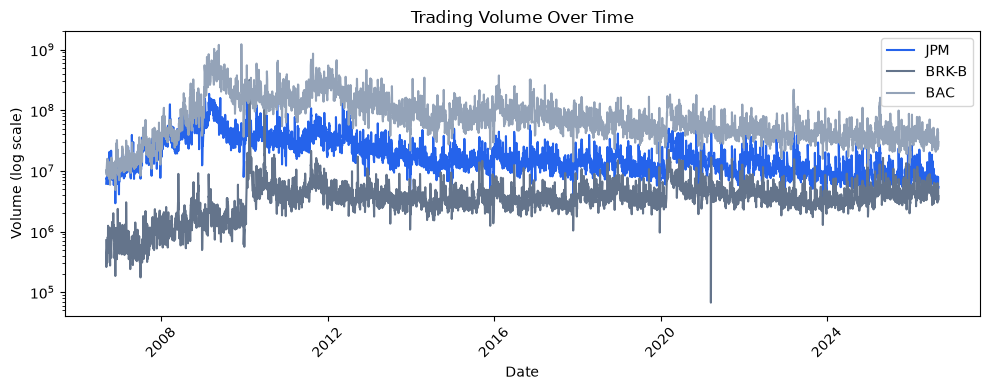

In [27]:
plt.figure(figsize=(10, 4))

for ticker, color in zip(selected_tickers, colors):
    stock = (
        exploration_pd[
            exploration_pd["ticker"] == ticker
        ]
        .sort_values("Date")
    )

    plt.plot(
        stock["Date"],
        stock["Volume"],
        label=ticker,
        color=color
    )

plt.yscale("log")

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume (log scale)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "trading_volume_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 20-Day Rolling Volatility

This visualization shows the 20-day rolling standard deviation of daily returns and provides a view of how price variability changes over time.

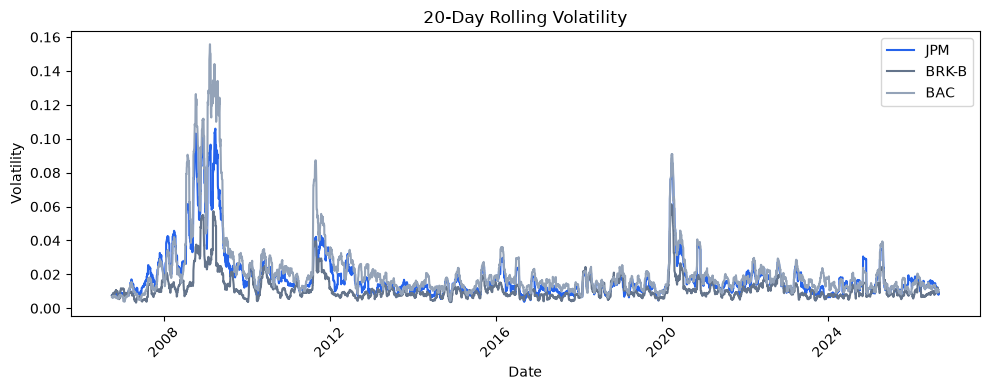

In [28]:
plt.figure(figsize=(10, 4))

for ticker, color in zip(selected_tickers, colors):
    stock = (
        exploration_pd[
            exploration_pd["ticker"] == ticker
        ]
        .sort_values("Date")
        .copy()
    )

    returns = stock["Close"].pct_change()

    volatility = returns.rolling(20).std()

    plt.plot(
        stock["Date"],
        volatility,
        label=ticker,
        color=color
    )

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "rolling_volatility_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# Gold

The Gold layer transforms the validated Silver dataset into a curated analytical dataset by creating derived financial features and a prediction target.  Time-series calculations are performed independently for each ticker, producing measures such as daily returns, moving averages, rolling volatility, volume trends and normalized price trends.  

>A binary price-direction label is also created for downstream modeling and decision-support analysis.

The transformation from Silver to Gold follows this structure:
```
data/
├── silver/
│   ├── ticker=AAPL/
│   │   └── part-*.parquet
│   ├── ticker=MSFT/
│   │   └── part-*.parquet
│   └── ...
│
└── gold/
    ├── ticker=AAPL/
    │   └── part-*.parquet
    ├── ticker=MSFT/
    │   └── part-*.parquet
    └── ...
```

## Read & Validate Silver Layer

Reading the cleaned Silver dataset into Spark and validating the row count, column structure, schema and sample records before applying Gold-layer transformations.

In [29]:
silver_df = spark.read.parquet(str(SILVER_DIR))

print(f"Rows: {silver_df.count():,}")
print(f"Columns: {len(silver_df.columns)}")

silver_df.printSchema()

silver_df.show(5, truncate=False, vertical=True)

Rows: 97,488
Columns: 11
root
 |-- Date: date (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- download_timestamp: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ticker: string (nullable = true)

-RECORD 0----------------------------------------------
 Date               | 2008-10-01                       
 Adj Close          | 0.2383154183626175               
 Open               | 0.2637499868869781               
 High               | 0.2685000002384186               
 Low                | 0.2554999887943268               
 Close              | 0.2602500021457672               
 Volume             | 557208000                        
 download_timestamp | 2026-09-04 18:55:30.047632+00:00 
 year               | 2008                     

## Financial Data Engineering

### Price Features

#### Time-Series Window

Defining a time-series window that independently orders each ticker's observations by date.  This step provides the framework for calculating rolling and lagged financial features.

In [30]:
time_window = (
    Window
    .partitionBy("ticker")
    .orderBy("Date")
)

#### Daily Returns

Calculating daily returns for each ticker by comparing the current closing price with the previous trading day's closing price within the configured time-series window.

In [31]:
gold_df = (
    silver_df
    .withColumn(
        "previous_close",
        F.lag("Close").over(time_window)
    )
    .withColumn(
        "daily_return",
        (F.col("Close") - F.col("previous_close"))
        / F.col("previous_close")
    )
)

#### Log Returns

Calculating the logarithmic return between the current and previous closing prices.  This feature provides an alternative representation of daily price movement.

In [32]:
gold_df = gold_df.withColumn(
    "log_return",
    F.log(F.col("Close") / F.col("previous_close"))
)

#### Price Change

Calculating the absolute change in closing price between the current and previous observations for each ticker.

In [33]:
gold_df = gold_df.withColumn(
    "price_change",
    (F.col("Close") - F.col("previous_close"))
)

#### Verify Price Features

In [34]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "daily_return",
    "log_return",
    "price_change"
).show(5)

+------+----------+------------------+--------------------+--------------------+--------------------+
|ticker|      Date|             Close|        daily_return|          log_return|        price_change|
+------+----------+------------------+--------------------+--------------------+--------------------+
|  AAPL|2006-09-05| 2.552856922149658|                NULL|                NULL|                NULL|
|  AAPL|2006-09-06| 2.501070976257324|-0.02028548699420535|-0.02049406301686...|-0.05178594589233...|
|  AAPL|2006-09-07|2.5999999046325684| 0.03955462652374795|0.038792377703583514| 0.09892892837524414|
|  AAPL|2006-09-08|2.5899999141693115|-0.00384615031925...|-0.00385356577547...|-0.00999999046325...|
|  AAPL|2006-09-11|2.5892860889434814|-2.75608204434641E-4|-2.75646191355626...|-7.13825225830078...|
+------+----------+------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


### Trend Features

#### Rolling Windows

Defining 5-, 20-, and 50-trading-day rolling windows for each ticker.  These windows are reused across multiple financial features including moving averages and rolling volatility.

In [35]:
rolling_window_5 = (
    Window
    .partitionBy("ticker")
    .orderBy("Date")
    .rowsBetween(-4, 0)
)

rolling_window_20 = (
    Window
    .partitionBy("ticker")
    .orderBy("Date")
    .rowsBetween(-19, 0)
)

rolling_window_50 = (
    Window
    .partitionBy("ticker")
    .orderBy("Date")
    .rowsBetween(-49, 0)
)

#### Closing Price Moving Averages

Calculating 5-, 20-, and 50-trading-day moving averages of closing price for each ticker using the previously defined rolling windows.

In [36]:
gold_df = (
    gold_df
    .withColumn("ma_5", F.avg("Close").over(rolling_window_5))
    .withColumn("ma_20", F.avg("Close").over(rolling_window_20))
    .withColumn("ma_50", F.avg("Close").over(rolling_window_50))
)

#### Normalized Price Trends

Calculating the closing price relative to its 5-, 20- and 50-trading-day moving averages.  These features provide a normalized measure of each stock's current price position relative to its recent trends.

In [37]:
gold_df = (
    gold_df
    .withColumn("price_vs_ma5", F.col("Close") / F.col("ma_5"))
    .withColumn("price_vs_ma20", F.col("Close") / F.col("ma_20"))    
    .withColumn("price_vs_ma50", F.col("Close") / F.col("ma_50"))                
)

#### Verify Trend Features

In [38]:
# moving averages
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "ma_5",
    "ma_20",
    "ma_50"
).show(5)

+------+----------+------------------+------------------+------------------+------------------+
|ticker|      Date|             Close|              ma_5|             ma_20|             ma_50|
+------+----------+------------------+------------------+------------------+------------------+
|  AAPL|2006-09-05| 2.552856922149658| 2.552856922149658| 2.552856922149658| 2.552856922149658|
|  AAPL|2006-09-06| 2.501070976257324| 2.526963949203491| 2.526963949203491| 2.526963949203491|
|  AAPL|2006-09-07|2.5999999046325684|  2.55130926767985|  2.55130926767985|  2.55130926767985|
|  AAPL|2006-09-08|2.5899999141693115|2.5609819293022156|2.5609819293022156|2.5609819293022156|
|  AAPL|2006-09-11|2.5892860889434814|2.5666427612304688|2.5666427612304688|2.5666427612304688|
+------+----------+------------------+------------------+------------------+------------------+
only showing top 5 rows


In [39]:
# normalized trends
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50"
).show(5)

+------+----------+------------------+------------------+------------------+------------------+
|ticker|      Date|             Close|      price_vs_ma5|     price_vs_ma20|     price_vs_ma50|
+------+----------+------------------+------------------+------------------+------------------+
|  AAPL|2006-09-05| 2.552856922149658|               1.0|               1.0|               1.0|
|  AAPL|2006-09-06| 2.501070976257324|0.9897533271282606|0.9897533271282606|0.9897533271282606|
|  AAPL|2006-09-07|2.5999999046325684|1.0190845686838261|1.0190845686838261|1.0190845686838261|
|  AAPL|2006-09-08|2.5899999141693115| 1.011330804225941| 1.011330804225941| 1.011330804225941|
|  AAPL|2006-09-11|2.5892860889434814|1.0088221579002126|1.0088221579002126|1.0088221579002126|
+------+----------+------------------+------------------+------------------+------------------+
only showing top 5 rows


### Risk Features

####  Rolling Volatility

Calculating 5-, 20-, 50-period rolling volatility as the standard deviation of daily returns within the defined rolling window.

In [40]:
gold_df = (
    gold_df
    .withColumn("volatility_5", F.stddev("daily_return").over(rolling_window_5))
    .withColumn("volatility_20", F.stddev("daily_return").over(rolling_window_20))
    .withColumn("volatility_50", F.stddev("daily_return").over(rolling_window_50))
)

#### Verify Risk Features

In [41]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "volatility_5",
    "volatility_20",
    "volatility_50"
).show(10)

+------+----------+------------------+--------------------+--------------------+--------------------+
|ticker|      Date|             Close|        volatility_5|       volatility_20|       volatility_50|
+------+----------+------------------+--------------------+--------------------+--------------------+
|  AAPL|2006-09-05| 2.552856922149658|                NULL|                NULL|                NULL|
|  AAPL|2006-09-06| 2.501070976257324|                NULL|                NULL|                NULL|
|  AAPL|2006-09-07|2.5999999046325684| 0.04231335005551757| 0.04231335005551757| 0.04231335005551757|
|  AAPL|2006-09-08|2.5899999141693115|0.030915795333803793|0.030915795333803793|0.030915795333803793|
|  AAPL|2006-09-11|2.5892860889434814|0.025387513376669685|0.025387513376669685|0.025387513376669685|
|  AAPL|2006-09-12|2.5939290523529053|0.022004302882408604|0.022004302882408604|0.022004302882408604|
|  AAPL|2006-09-13|2.6500000953674316|0.018421677178598335|0.021041128238470007|0.

### Volume Features

#### 20-Period Volume Trend

Calculating the 20-period rolling average trading volume for each ticker to provide a measure of recent trading activity.

In [42]:
gold_df = gold_df.withColumn(
    "avg_volume_20",
    F.avg("Volume").over(rolling_window_20)
)

#### Verify Volume Features

In [43]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "avg_volume_20"
).show(5)

+------+----------+------------------+--------------------+
|ticker|      Date|             Close|       avg_volume_20|
+------+----------+------------------+--------------------+
|  AAPL|2006-09-05| 2.552856922149658|         1.0124576E9|
|  AAPL|2006-09-06| 2.501070976257324|          9.932804E8|
|  AAPL|2006-09-07|2.5999999046325684|1.0848394666666667E9|
|  AAPL|2006-09-08|2.5899999141693115|           1.03761E9|
|  AAPL|2006-09-11|2.5892860889434814|        1.01991288E9|
+------+----------+------------------+--------------------+
only showing top 5 rows


### Momentum Features

#### 20-Period Momentum

Calculating 20-trading-day price momentum as the percentage change in closing price relative to the closing price 20 trading days earlier.

In [44]:
gold_df = gold_df.withColumn(
    "momentum_20",
    (F.col("Close") / F.lag("Close", 20).over(time_window)) - 1
)

#### Verify Momentum Features

In [45]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "momentum_20"
).show(21)

+------+----------+------------------+-------------------+
|ticker|      Date|             Close|        momentum_20|
+------+----------+------------------+-------------------+
|  AAPL|2006-09-05| 2.552856922149658|               NULL|
|  AAPL|2006-09-06| 2.501070976257324|               NULL|
|  AAPL|2006-09-07|2.5999999046325684|               NULL|
|  AAPL|2006-09-08|2.5899999141693115|               NULL|
|  AAPL|2006-09-11|2.5892860889434814|               NULL|
|  AAPL|2006-09-12|2.5939290523529053|               NULL|
|  AAPL|2006-09-13|2.6500000953674316|               NULL|
|  AAPL|2006-09-14|2.6489291191101074|               NULL|
|  AAPL|2006-09-15|2.6464290618896484|               NULL|
|  AAPL|2006-09-18|2.6389288902282715|               NULL|
|  AAPL|2006-09-19| 2.634643077850342|               NULL|
|  AAPL|2006-09-20| 2.687856912612915|               NULL|
|  AAPL|2006-09-21|2.6660709381103516|               NULL|
|  AAPL|2006-09-22| 2.607142925262451|               NUL

### Prediction Target

The prediction target defines the future outcome used for downstream modeling.  The target is constructed from the next trading observation.  The previously engineered features are based only on information available at the current observation.

#### Next-Period Closing Price

Creating a next-period closing price by using the following trading observation for each ticker.  This variable provides the basis for the future-price target defined in the next step.

In [46]:
gold_df = gold_df.withColumn(
    "next_close",
    F.lead("Close").over(time_window)
)

#### Create Binary Direction Label

Converting the next-period price into a binary direction label.  `1` is assigned when the next closing price is higher than the current price and `0` is assigned otherwise.

In [47]:
gold_df = gold_df.withColumn(
    "next_day_up",
    F.when(F.col("next_close") > F.col("Close"), 1).otherwise(0)
)

#### Verify Prediction Target

In [48]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "next_close",
    "next_day_up"
).show(10)

+------+----------+------------------+------------------+-----------+
|ticker|      Date|             Close|        next_close|next_day_up|
+------+----------+------------------+------------------+-----------+
|  AAPL|2006-09-05| 2.552856922149658| 2.501070976257324|          0|
|  AAPL|2006-09-06| 2.501070976257324|2.5999999046325684|          1|
|  AAPL|2006-09-07|2.5999999046325684|2.5899999141693115|          0|
|  AAPL|2006-09-08|2.5899999141693115|2.5892860889434814|          0|
|  AAPL|2006-09-11|2.5892860889434814|2.5939290523529053|          1|
|  AAPL|2006-09-12|2.5939290523529053|2.6500000953674316|          1|
|  AAPL|2006-09-13|2.6500000953674316|2.6489291191101074|          0|
|  AAPL|2006-09-14|2.6489291191101074|2.6464290618896484|          0|
|  AAPL|2006-09-15|2.6464290618896484|2.6389288902282715|          0|
|  AAPL|2006-09-18|2.6389288902282715| 2.634643077850342|          0|
+------+----------+------------------+------------------+-----------+
only showing top 10 

## Finalize Gold Dataset

### Remove Incomplete Feature Rows

Removing observations that do not contain the complete set of derived features and prediction-target fields required for downstream analysis and modeling.

In [49]:
gold_df = gold_df.dropna(
    subset=[
        "daily_return",
        "log_return",
        "price_change",
        "ma_5",
        "ma_20",
        "ma_50",
        "price_vs_ma5",
        "price_vs_ma20",
        "price_vs_ma50",
        "volatility_5",
        "volatility_20",
        "volatility_50",
        "avg_volume_20",
        "momentum_20",
        "next_close",
        "next_day_up"
    ]
)

### Remove Intermediate Columns

Removing intermediate columns (`previous_close`, `next_close`) used to calculate the engineered features and prediction label.  This leaves only the fields required in the final Gold dataset.

In [50]:
cols_to_drop = [
    "previous_close",
    "next_close"
]

gold_df = gold_df.drop(*cols_to_drop)

### Validate Gold Dataset

Summarizing the completed Gold dataset by reviewing its schema, final dimensions, ticker coverage, date range and record counts by ticker.

In [51]:
gold_df.select(
    F.countDistinct("ticker").alias("Number of Tickers"),
    F.min("Date").alias("Start Date"),
    F.max("Date").alias("End Date")
).show()

print(f"Gold Row Count         : {gold_df.count():,}")
print(f"Gold Column Count      : {len(gold_df.columns)}\n")

gold_df.groupBy("ticker").count().orderBy("ticker").show()

gold_df.printSchema()

+-----------------+----------+----------+
|Number of Tickers|Start Date|  End Date|
+-----------------+----------+----------+
|               20|2006-10-03|2026-09-02|
+-----------------+----------+----------+

Gold Row Count         : 97,068
Gold Column Count      : 26

+------+-----+
|ticker|count|
+------+-----+
|  AAPL| 5010|
|  AMZN| 5010|
|  AVGO| 4275|
|   BAC| 5010|
| BRK-B| 5010|
|   CAT| 5010|
|    GE| 5010|
| GOOGL| 5010|
|   JNJ| 5010|
|   JPM| 5010|
|   LLY| 5010|
|  META| 3573|
|  MSFT| 5010|
|   NEE| 5010|
|  NVDA| 5010|
|  ORCL| 5010|
|    PG| 5010|
|  TSLA| 4050|
|   WMT| 5010|
|   XOM| 5010|
+------+-----+

root
 |-- Date: date (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- download_timestamp: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer 

### Validate Gold Features

Sampling the completed Gold dataset to verify that the underlying market data, engineered features and prediction label are populated and available for downstream analysis and modeling.

In [52]:
gold_df.select(
    "ticker",
    "Date",
    "Close",
    "daily_return",
    "log_return",
    "price_change",
    "ma_5",
    "ma_20",
    "ma_50",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50",
    "volatility_5",
    "volatility_20",
    "volatility_50",
    "avg_volume_20",
    "momentum_20",
    "next_day_up"
).show(1, truncate=False, vertical=True)

-RECORD 0------------------------------
 ticker        | AAPL                  
 Date          | 2006-10-03            
 Close         | 2.645714044570923     
 daily_return  | -0.010419421835832195 
 log_return    | -0.010474084042117459 
 price_change  | -0.027857065200805664 
 ma_5          | 2.7095714092254637    
 ma_20         | 2.6539643526077272    
 ma_50         | 2.649149713062105     
 price_vs_ma5  | 0.9764326695959659    
 price_vs_ma20 | 0.9968913267321402    
 price_vs_ma50 | 0.9987031051985314    
 volatility_5  | 0.013651443517183406  
 volatility_20 | 0.01856591756269158   
 volatility_50 | 0.01856591756269158   
 avg_volume_20 | 8.901977E8            
 momentum_20   | 0.03637380599578344   
 next_day_up   | 1                     
only showing top 1 row


## Write Gold Dataset

Writing the completed Gold dataset to partitioned Parquet files, using one partition per ticker for efficient downstream access.

In [53]:
GOLD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

(
    gold_df
    .coalesce(10)
    .write
    .mode("overwrite")
    .partitionBy("ticker")
    .parquet(str(GOLD_DIR))
)
print(f"Gold dataset written to: {GOLD_DIR}")

[Stage 80:======================================>                   (2 + 1) / 3]

Gold dataset written to: /Users/rnitto/Projects/coursework/big_data/final_project/data/gold


## Validate Persisted Gold Dataset

Reading the persisted Gold dataset back from Parquet and verifies that the schema and record count are preserved after writing.

In [54]:
gold_df = spark.read.parquet(str(GOLD_DIR))

gold_df.select(
    F.countDistinct("ticker").alias("Number of Tickers"),
    F.min("Date").alias("Start Date"),
    F.max("Date").alias("End Date")
).show()

print(f"Gold Row Count         : {gold_df.count():,}")
print(f"Gold Column Count      : {len(gold_df.columns)}\n")

gold_df.groupBy("ticker").count().orderBy("ticker").show()

gold_df.printSchema()

+-----------------+----------+----------+
|Number of Tickers|Start Date|  End Date|
+-----------------+----------+----------+
|               20|2006-10-03|2026-09-02|
+-----------------+----------+----------+

Gold Row Count         : 97,068
Gold Column Count      : 26

+------+-----+
|ticker|count|
+------+-----+
|  AAPL| 5010|
|  AMZN| 5010|
|  AVGO| 4275|
|   BAC| 5010|
| BRK-B| 5010|
|   CAT| 5010|
|    GE| 5010|
| GOOGL| 5010|
|   JNJ| 5010|
|   JPM| 5010|
|   LLY| 5010|
|  META| 3573|
|  MSFT| 5010|
|   NEE| 5010|
|  NVDA| 5010|
|  ORCL| 5010|
|    PG| 5010|
|  TSLA| 4050|
|   WMT| 5010|
|   XOM| 5010|
+------+-----+

root
 |-- Date: date (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- download_timestamp: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer 

## Feature Exploration

In [55]:
# creating gold dataframe
gold_viz_pd = (
    gold_df
    .filter(F.col("ticker").isin(selected_tickers))
    .toPandas()
    .sort_values(["ticker", "Date"])
)

### Moving Average Relationships - JPM

This visualization examines the relationship between JPM's adjusted closing price and its 5-, 20- and 50-day moving averages over time.

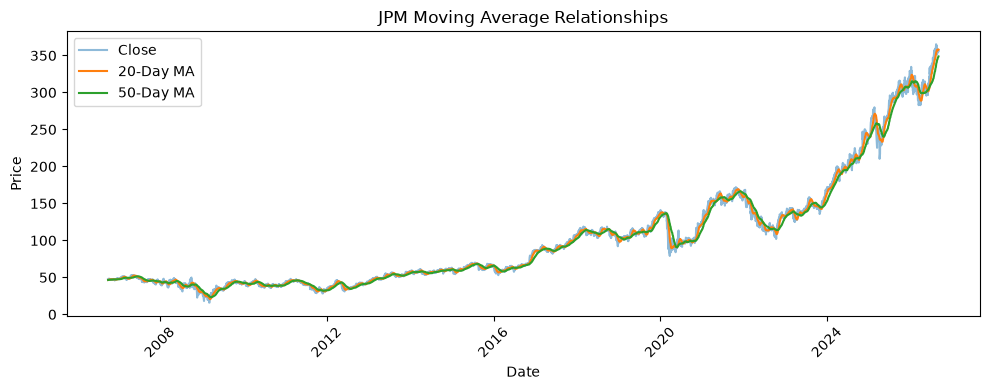

In [56]:
plt.figure(figsize=(10, 4))

stock = (
    gold_viz_pd[
        gold_viz_pd["ticker"] == selected_tickers[0]
    ]
    .sort_values("Date")
)

plt.plot(
    stock["Date"],
    stock["Close"],
    label="Close",
    alpha=0.5
)

plt.plot(
    stock["Date"],
    stock["ma_20"],
    label="20-Day MA"
)

plt.plot(
    stock["Date"],
    stock["ma_50"],
    label="50-Day MA"
)

plt.title(f"{selected_tickers[0]} Moving Average Relationships")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "jpm_moving_average_relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Volatility Behavior

This visualization examines how rolling volatility varies over time across the securities in the dataset.

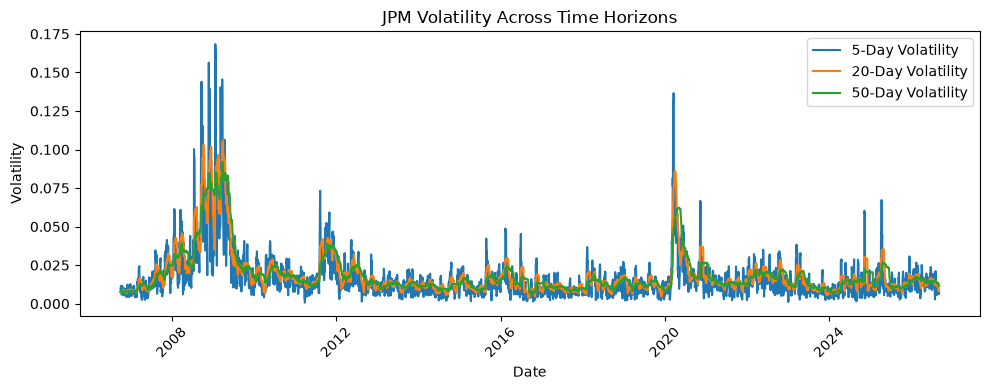

In [57]:
plt.figure(figsize=(10, 4))

plt.plot(
    stock["Date"],
    stock["volatility_5"],
    label="5-Day Volatility"
)

plt.plot(
    stock["Date"],
    stock["volatility_20"],
    label="20-Day Volatility"
)

plt.plot(
    stock["Date"],
    stock["volatility_50"],
    label="50-Day Volatility"
)

plt.title(f"{selected_tickers[0]} Volatility Across Time Horizons")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "volatility_time_horizons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Momentum

This visualization examines price momentum using the relationship between current prices and their moving averages.

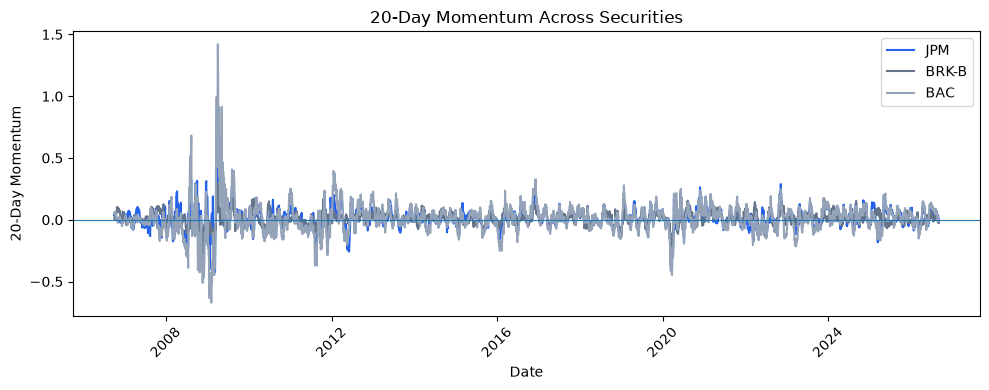

In [58]:
plt.figure(figsize=(10, 4))

for ticker, color in zip(selected_tickers, colors):
    stock = (
        gold_viz_pd[
            gold_viz_pd["ticker"] == ticker
        ]
        .sort_values("Date")
    )

    plt.plot(
        stock["Date"],
        stock["momentum_20"],
        label=ticker,
        color=color
    )

plt.axhline(0, linewidth=0.8)

plt.title("20-Day Momentum Across Securities")
plt.xlabel("Date")
plt.ylabel("20-Day Momentum")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "momentum_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log Returns Distribution

This distribution shows the frequency and spread of logarithmic daily returns across the securities in the dataset.

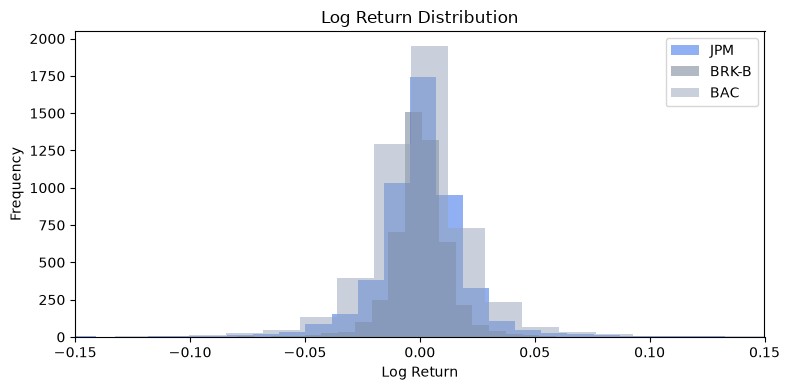

In [59]:
plt.figure(figsize=(8, 4))

for ticker, color in zip(selected_tickers, colors):
    returns = (
        gold_viz_pd[
            gold_viz_pd["ticker"] == ticker
        ]["log_return"]
        .dropna()
    )

    plt.hist(
        returns,
        bins=40,
        alpha=0.5,
        label=ticker,
        color=color
    )

plt.xlim(-0.15, 0.15)

plt.title("Log Return Distribution")
plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "log_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature Correlation

This visualization examines the relationships among the engineered features and identifies the strength and direction of their linear associations.

In [60]:
numeric_feature_cols = [
    "daily_return",
    "log_return",
    "price_change",
    "ma_5",
    "ma_20",
    "ma_50",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50",
    "volatility_5",
    "volatility_20",
    "volatility_50",
    "avg_volume_20",
    "momentum_20"
]

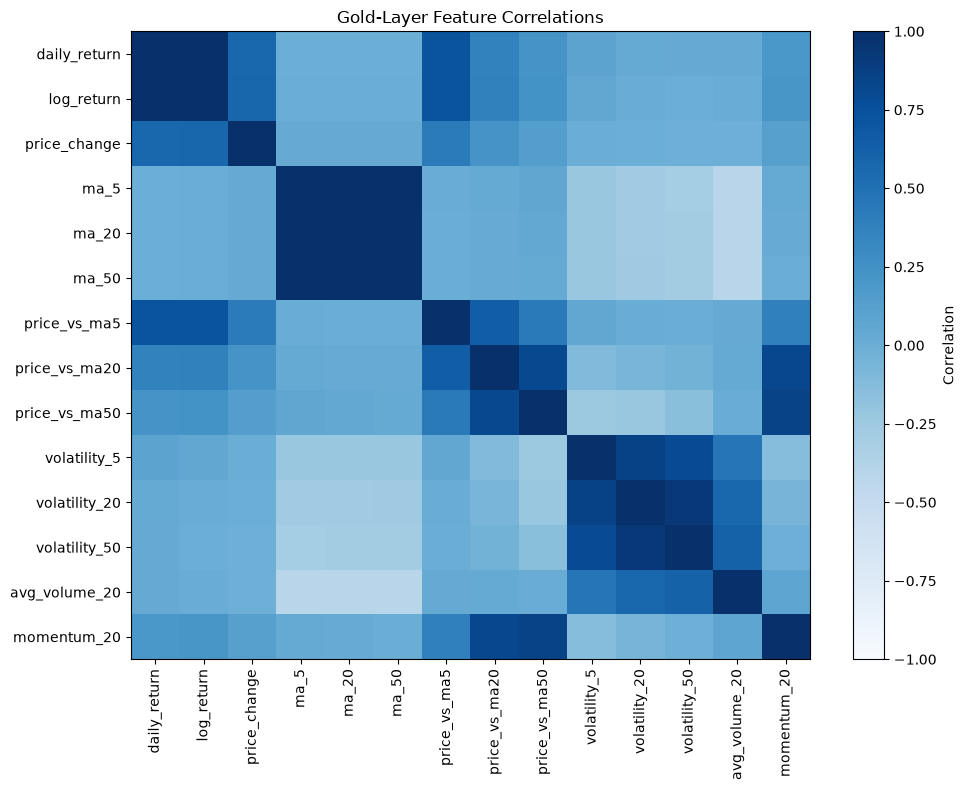

In [61]:
corr = gold_viz_pd[numeric_feature_cols].corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    corr,
    aspect="auto",
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(numeric_feature_cols)),
    numeric_feature_cols,
    rotation=90
)

plt.yticks(
    range(len(numeric_feature_cols)),
    numeric_feature_cols
)

plt.colorbar(label="Correlation")

plt.title("Gold-Layer Feature Correlations")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "gold_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
corr

,daily_return,log_return,price_change,ma_5,ma_20,ma_50,price_vs_ma5,price_vs_ma20,price_vs_ma50,volatility_5,volatility_20,volatility_50,avg_volume_20,momentum_20
daily_return,1.000000,0.997900,0.576921,-0.001195,-0.001902,-0.001787,0.719141,0.362729,0.225732,0.092039,0.038604,0.027383,0.028505,0.199264
log_return,0.997900,1.000000,0.578913,0.004833,0.003999,0.003954,0.724897,0.372729,0.238645,0.056472,0.008181,-0.000905,0.012672,0.207350
price_change,0.576921,0.578913,1.000000,0.026642,0.025302,0.025468,0.418796,0.221704,0.140457,0.003292,-0.005565,-0.010258,-0.010014,0.121468
ma_5,-0.001195,0.004833,0.026642,1.000000,0.999523,0.998485,0.010438,0.038249,0.065869,-0.234336,-0.269206,-0.289428,-0.421131,0.032558
ma_20,-0.001902,0.003999,0.025302,0.999523,1.000000,0.999339,0.006217,0.022123,0.052081,-0.230606,-0.267448,-0.288164,-0.421325,0.017678
ma_50,-0.001787,0.003954,0.025468,0.998485,0.999339,1.000000,0.005742,0.015900,0.035393,-0.224863,-0.261039,-0.283789,-0.421034,0.006217
price_vs_ma5,0.719141,0.724897,0.418796,0.010438,0.006217,0.005742,1.000000,0.646044,0.422133,0.059755,0.013019,0.000520,0.027752,0.375974
price_vs_ma20,0.362729,0.372729,0.221704,0.038249,0.022123,0.015900,0.646044,1.000000,0.809292,-0.116195,-0.063860,-0.046313,0.035762,0.819707
price_vs_ma50,0.225732,0.238645,0.140457,0.065869,0.052081,0.035393,0.422133,0.809292,1.000000,-0.248051,-0.228768,-0.150883,0.013165,0.845469
volatility_5,0.092039,0.056472,0.003292,-0.234336,-0.230606,-0.224863,0.059755,-0.116195,-0.248051,1.000000,0.852420,0.784012,0.468654,-0.136294


---

# Experiment 1 - Logisitc Regression with Full Feature Set

The first experiment uses a Logistic Regression model with the purpose-built set of engineered financial features from the Gold layer.

In [63]:
# reading gold directory to create dataset for experimentation
gold_df = spark.read.parquet(str(GOLD_DIR))

## Feature Selection

In [64]:
# full feature set
experiment_1_features = [
    "daily_return",
    "log_return",
    "price_change",
    "ma_5",
    "ma_20",
    "ma_50",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50",
    "volatility_5",
    "volatility_20",
    "volatility_50",
    "avg_volume_20",
    "momentum_20"
]

# defining target
target_col = "next_day_up"

# creating experiment 1 df
experiment_1_df = gold_df.select(
    "ticker",
    "Date",
    *experiment_1_features,
    target_col
)

experiment_1_df.printSchema()

print(f"Rows: {experiment_1_df.count():,}")
print(f"Features: {len(experiment_1_features)}")

root
 |-- ticker: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- daily_return: double (nullable = true)
 |-- log_return: double (nullable = true)
 |-- price_change: double (nullable = true)
 |-- ma_5: double (nullable = true)
 |-- ma_20: double (nullable = true)
 |-- ma_50: double (nullable = true)
 |-- price_vs_ma5: double (nullable = true)
 |-- price_vs_ma20: double (nullable = true)
 |-- price_vs_ma50: double (nullable = true)
 |-- volatility_5: double (nullable = true)
 |-- volatility_20: double (nullable = true)
 |-- volatility_50: double (nullable = true)
 |-- avg_volume_20: double (nullable = true)
 |-- momentum_20: double (nullable = true)
 |-- next_day_up: integer (nullable = true)

Rows: 97,068
Features: 14


In [65]:
experiment_1_df.groupBy("next_day_up").count().orderBy("next_day_up").show()

+-----------+-----+
|next_day_up|count|
+-----------+-----+
|          0|46749|
|          1|50319|
+-----------+-----+



## Train/Test Split

A chronological train/test split is used because the dataset represents historical financial observations where future information should not be used to train the model.  The split is based on distinct trading dates rather than individual rows so that all tickers are separated at the same point in time. Using a dynamic 80/20 split allows the training and testing periods to automatically adjust as new market data is added to the pipeline.

In [66]:
# calculating chronological split date
dates = (
    experiment_1_df
    .select("Date")
    .distinct()
    .orderBy("Date")
    .collect()
)

split_date = dates[int(len(dates) * 0.8)]["Date"]

print(f"Training data through: {split_date}")

Training data through: 2022-09-06


In [67]:
# splitting based on split_date
train_1_df = experiment_1_df.filter(
    F.col("Date") < split_date
)

test_1_df = experiment_1_df.filter(
    F.col("Date") >= split_date
)

print(f"Training rows: {train_1_df.count():,}")
train_1_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

print(f"Test rows:     {test_1_df.count():,}")
test_1_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

Training rows: 77,028
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2006-10-03|2022-09-02|
+----------+----------+

Test rows:     20,040
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2022-09-06|2026-09-02|
+----------+----------+



## Model Pipeline

The model pipeline assembles the feature preparation and classification steps into a single repeatable workflow.  This ensures that the same transformations are applied consistently to the input features before generating predictions.

In [68]:
# using VectorAssembler
assembler_1 = VectorAssembler(
    inputCols=experiment_1_features,
    outputCol="assembled_features"
)

# applying standard scaling
scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

# defining logistic regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="next_day_up"
)

# organizing into a pipeline
lr_pipeline = Pipeline(
    stages=[
        assembler_1,
        scaler,
        lr
    ]
)

# fitting training data
lr_model_1 = lr_pipeline.fit(train_1_df)

## Generate Predictions

In [69]:
predictions_1 = lr_model_1.transform(test_1_df)

## Model Evaluation

This section evaluates model performance using multiple measures of classification effectiveness, including prediction probabilities, confusion matrices and classification metrics.

#### Prediction Probabilities

The predicted probability for each row represents the model's estimated likelihood that the observation belongs to the positive class (next_day_up = 1).  Examining the range of these probabilities provides a view of how confidently the model distinguishes between the two classes.

In [70]:
predictions_output_1 = predictions_1.select(
    "ticker",
    "Date",
    "next_day_up",
    "prediction",
    "probability"
)

predictions_output_1.show(10)

+------+----------+-----------+----------+--------------------+
|ticker|      Date|next_day_up|prediction|         probability|
+------+----------+-----------+----------+--------------------+
|  NVDA|2022-09-06|          1|       1.0|[0.45711226909507...|
|  NVDA|2022-09-07|          1|       1.0|[0.47735828537951...|
|  NVDA|2022-09-08|          1|       1.0|[0.48017145015516...|
|  NVDA|2022-09-09|          1|       1.0|[0.48372388548660...|
|  NVDA|2022-09-12|          0|       1.0|[0.47463116917287...|
|  NVDA|2022-09-13|          0|       1.0|[0.40942677696846...|
|  NVDA|2022-09-14|          0|       1.0|[0.49067273980978...|
|  NVDA|2022-09-15|          1|       1.0|[0.47865992402658...|
|  NVDA|2022-09-16|          1|       0.0|[0.50702081234710...|
|  NVDA|2022-09-19|          0|       1.0|[0.49863243694918...|
+------+----------+-----------+----------+--------------------+
only showing top 10 rows


Saving predictions and probabilities.

In [71]:
temp_dir = MODELING_DIR / "experiment_1" / "_predictions_temp"
final_file = MODELING_DIR / "experiment_1" / "predictions.csv"

(
    predictions_output_1
    .withColumn("probability", F.col("probability").cast("string"))
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Probability Summary

Quartile statistics summarize the distribution of predicted probabilities across all observations. 

In [72]:
probability_summary_1 = predictions_1.select(
    F.round(F.min(vector_to_array("probability")[1]), 4).alias("Min"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.25
        ), 4
    ).alias("25th"),
    F.round(
        F.avg(vector_to_array("probability")[1]), 4
    ).alias("Mean"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.50
        ), 4
    ).alias("Median"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.75
        ), 4
    ).alias("75th"),
    F.round(
        F.max(vector_to_array("probability")[1]), 4
    ).alias("Max")
)

probability_summary_1.show()

+------+------+------+------+------+------+
|   Min|  25th|  Mean|Median|  75th|   Max|
+------+------+------+------+------+------+
|0.2466|0.4966|0.5057| 0.509|0.5186|0.7126|
+------+------+------+------+------+------+



Saving the probability summary.

In [73]:
temp_dir = MODELING_DIR / "experiment_1" / "_probability_summary_temp"
final_file = MODELING_DIR / "experiment_1" / "probability_summary.csv"

(
    probability_summary_1
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Normalized Confusion Matrix

The normalized confusion matrix shows each prediction outcome as a proportion of the actual class.  This can make it easier to compare classification performance across the two classes regardless of their sample sizes.

In [74]:
confusion_counts = (
    predictions_1
    .groupBy("next_day_up", "prediction")
    .count()
)

row_totals = (
    confusion_counts
    .groupBy("next_day_up")
    .agg(F.sum("count").alias("actual_total"))
)

confusion_normalized = (
    confusion_counts
    .join(row_totals, on="next_day_up")
    .withColumn(
        "proportion",
        F.col("count") / F.col("actual_total")
    )
    .orderBy("next_day_up", "prediction")
)

confusion_normalized.show()

+-----------+----------+-----+------------+-------------------+
|next_day_up|prediction|count|actual_total|         proportion|
+-----------+----------+-----+------------+-------------------+
|          0|       0.0| 2844|        9364|0.30371636052968815|
|          0|       1.0| 6520|        9364| 0.6962836394703118|
|          1|       0.0| 3233|       10676|0.30282877482203074|
|          1|       1.0| 7443|       10676| 0.6971712251779693|
+-----------+----------+-----+------------+-------------------+



Saving the normalized confusion matrix.

In [75]:
temp_dir = MODELING_DIR / "experiment_1" / "_confusion_matrix_temp"
final_file = MODELING_DIR / "experiment_1" / "confusion_matrix.csv"

(
    confusion_normalized
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Confusion Matrix Heatmap

The confusion matrix heatmap provides a visual representation of the model's classification results.

In [76]:
# converting to pandas dataframe for plotting
cm_df = (
    confusion_counts
    .toPandas()
    .pivot(
        index="next_day_up",
        columns="prediction",
        values="count"
    )
    .fillna(0)
)

cm_df.index = ["Down / No Increase", "Up"]
cm_df.columns = ["Down / No Increase", "Up"]

cm_norm = cm_df.div(
    cm_df.sum(axis=1),
    axis=0
)

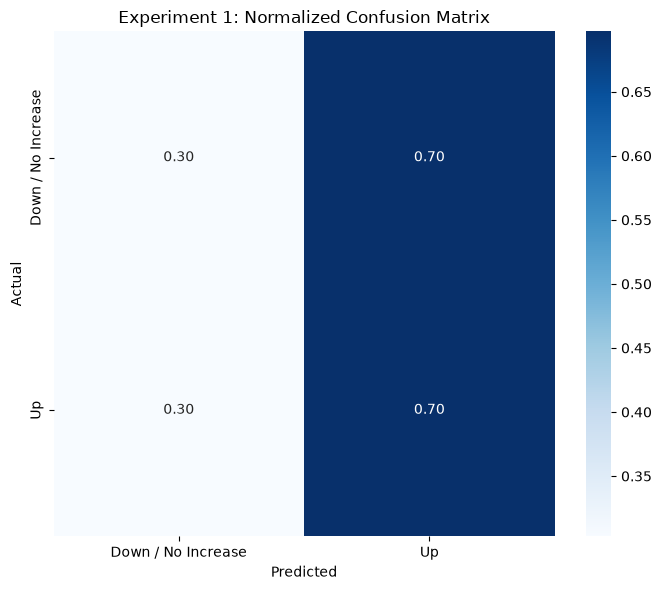

In [77]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Experiment 1: Normalized Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()

plt.savefig(
    str(MODELING_DIR / "experiment_1" / "normalized_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Classification Report

The classification report summarizes model performance for each class using accuracy, precision, recall, and F1 scores.

In [78]:
# using multi-class classficiation evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="next_day_up",
    predictionCol="prediction"
)

accuracy_1 = evaluator.evaluate(
    predictions_1,
    {evaluator.metricName: "accuracy"}
)

weighted_precision_1 = evaluator.evaluate(
    predictions_1,
    {evaluator.metricName: "weightedPrecision"}
)

weighted_recall_1 = evaluator.evaluate(
    predictions_1,
    {evaluator.metricName: "weightedRecall"}
)

f1_1 = evaluator.evaluate(
    predictions_1,
    {evaluator.metricName: "f1"}
)

print(f"Accuracy:           {accuracy_1:.4f}")
print(f"Weighted Precision: {weighted_precision_1:.4f}")
print(f"Weighted Recall:    {weighted_recall_1:.4f}")
print(f"F1 Score:           {f1_1:.4f}")

Accuracy:           0.5133
Weighted Precision: 0.5027
Weighted Recall:    0.5133
F1 Score:           0.4940


Saving Classification Report.

In [79]:
classification_report_1 = spark.createDataFrame([
    ("Experiment 1", "Accuracy", accuracy_1),
    ("Experiment 1", "Weighted Precision", weighted_precision_1),
    ("Experiment 1", "Weighted Recall", weighted_recall_1),
    ("Experiment 1", "F1 Score", f1_1)
], ["experiment", "metric", "value"])

temp_dir = MODELING_DIR / "experiment_1" / "_classification_report_temp"
final_file = MODELING_DIR / "experiment_1" / "classification_report.csv"

(
    classification_report_1
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

# Experiment 2 - Gradient Boosted Trees with Full Dataset

The second experiment replaces the logistic regression model with a Gradient-Boosted Tree (GBT) classifier using the same feature set as Experiment 1.

## Feature Selection

In [80]:
# same features as Experiment 1
experiment_2_features = [
    "daily_return",
    "log_return",
    "price_change",
    "ma_5",
    "ma_20",
    "ma_50",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50",
    "volatility_5",
    "volatility_20",
    "volatility_50",
    "avg_volume_20",
    "momentum_20"
]

target_col = "next_day_up"

experiment_2_df = gold_df.select(
    "ticker",
    "Date",
    *experiment_2_features,
    target_col
)

experiment_2_df.printSchema()

print(f"Rows: {experiment_2_df.count():,}")
print(f"Features: {len(experiment_2_features)}")

root
 |-- ticker: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- daily_return: double (nullable = true)
 |-- log_return: double (nullable = true)
 |-- price_change: double (nullable = true)
 |-- ma_5: double (nullable = true)
 |-- ma_20: double (nullable = true)
 |-- ma_50: double (nullable = true)
 |-- price_vs_ma5: double (nullable = true)
 |-- price_vs_ma20: double (nullable = true)
 |-- price_vs_ma50: double (nullable = true)
 |-- volatility_5: double (nullable = true)
 |-- volatility_20: double (nullable = true)
 |-- volatility_50: double (nullable = true)
 |-- avg_volume_20: double (nullable = true)
 |-- momentum_20: double (nullable = true)
 |-- next_day_up: integer (nullable = true)

Rows: 97,068
Features: 14


## Train/Test Split

In [81]:
dates = (
    experiment_2_df
    .select("Date")
    .distinct()
    .orderBy("Date")
    .collect()
)

split_date = dates[int(len(dates) * 0.8)]["Date"]

print(f"Training data through: {split_date}")

Training data through: 2022-09-06


In [82]:
train_2_df = experiment_2_df.filter(
    F.col("Date") < split_date
)

test_2_df = experiment_2_df.filter(
    F.col("Date") >= split_date
)

print(f"Training rows: {train_2_df.count():,}")
train_2_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

print(f"Test rows:     {test_2_df.count():,}")
test_2_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

Training rows: 77,028
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2006-10-03|2022-09-02|
+----------+----------+

Test rows:     20,040
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2022-09-06|2026-09-02|
+----------+----------+



## Model Pipeline

In [83]:
assembler_2 = VectorAssembler(
    inputCols=experiment_2_features,
    outputCol="features"
)

gbt = GBTClassifier(
    featuresCol="features",
    labelCol=target_col,
    maxIter=50,
    maxDepth=5,
    stepSize=0.1,
    seed=SEED
)

gbt_pipeline_2 = Pipeline(
    stages=[
        assembler_2,
        gbt
    ]
)

gbt_model_2 = gbt_pipeline_2.fit(train_2_df)

## Generate Predictions

In [84]:
predictions_2 = gbt_model_2.transform(test_2_df)

## Model Evaluation

#### Prediction Probabilities

In [85]:
predictions_2.select(
    "ticker",
    "Date",
    "next_day_up",
    "prediction",
    "probability"
).show(10, truncate=False)

+------+----------+-----------+----------+---------------------------------------+
|ticker|Date      |next_day_up|prediction|probability                            |
+------+----------+-----------+----------+---------------------------------------+
|NVDA  |2022-09-06|1          |1.0       |[0.48329402662406196,0.516705973375938]|
|NVDA  |2022-09-07|1          |0.0       |[0.5732836455135103,0.4267163544864897]|
|NVDA  |2022-09-08|1          |1.0       |[0.3997512765406801,0.6002487234593199]|
|NVDA  |2022-09-09|1          |1.0       |[0.4425553085407348,0.5574446914592652]|
|NVDA  |2022-09-12|0          |0.0       |[0.5340377984216276,0.4659622015783724]|
|NVDA  |2022-09-13|0          |1.0       |[0.4842114374353488,0.5157885625646512]|
|NVDA  |2022-09-14|0          |0.0       |[0.5782122415951598,0.4217877584048402]|
|NVDA  |2022-09-15|1          |1.0       |[0.48329402662406196,0.516705973375938]|
|NVDA  |2022-09-16|1          |0.0       |[0.5647467463731469,0.4352532536268531]|
|NVD

Saving predictions and probabilities.

In [86]:
predictions_output_2 = predictions_2.select(
    "ticker",
    "Date",
    "next_day_up",
    "prediction",
    "probability"
)

temp_dir = MODELING_DIR / "experiment_2" / "_predictions_temp"
final_file = MODELING_DIR / "experiment_2" / "predictions.csv"

(
    predictions_output_2
    .withColumn("probability", F.col("probability").cast("string"))
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Probability Summary

In [87]:
probability_summary_2 = predictions_2.select(
    F.round(F.min(vector_to_array("probability")[1]), 4).alias("Min"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.25
        ), 4
    ).alias("25th"),
    F.round(
        F.avg(vector_to_array("probability")[1]), 4
    ).alias("Mean"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.50
        ), 4
    ).alias("Median"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.75
        ), 4
    ).alias("75th"),
    F.round(
        F.max(vector_to_array("probability")[1]), 4
    ).alias("Max")
)

probability_summary_2.show()

+------+------+------+------+------+------+
|   Min|  25th|  Mean|Median|  75th|   Max|
+------+------+------+------+------+------+
|0.1279|0.4821|0.5087|0.5112|0.5373|0.9161|
+------+------+------+------+------+------+



Saving probability summary.

In [88]:
temp_dir = MODELING_DIR / "experiment_2" / "_probability_summary_temp"
final_file = MODELING_DIR / "experiment_2" / "probability_summary.csv"

(
    probability_summary_2
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Normalized Confusion Matrix

In [89]:
confusion_counts = (
    predictions_2
    .groupBy("next_day_up", "prediction")
    .count()
)

row_totals = (
    confusion_counts
    .groupBy("next_day_up")
    .agg(F.sum("count").alias("actual_total"))
)

confusion_normalized = (
    confusion_counts
    .join(row_totals, on="next_day_up")
    .withColumn(
        "proportion",
        F.col("count") / F.col("actual_total")
    )
    .orderBy("next_day_up", "prediction")
)

confusion_normalized.show()

+-----------+----------+-----+------------+-------------------+
|next_day_up|prediction|count|actual_total|         proportion|
+-----------+----------+-----+------------+-------------------+
|          0|       0.0| 3647|        9364| 0.3894703118325502|
|          0|       1.0| 5717|        9364| 0.6105296881674498|
|          1|       0.0| 4164|       10676|0.39003372049456725|
|          1|       1.0| 6512|       10676| 0.6099662795054327|
+-----------+----------+-----+------------+-------------------+



Saving normalized confusion matrix.

In [90]:
temp_dir = MODELING_DIR / "experiment_2" / "_confusion_matrix_temp"
final_file = MODELING_DIR / "experiment_2" / "confusion_matrix.csv"

(
    confusion_normalized
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Confusion Matrix Heatmap

In [91]:
# converting to pandas dataframe for plotting
cm_df = (
    confusion_counts
    .toPandas()
    .pivot(
        index="next_day_up",
        columns="prediction",
        values="count"
    )
    .fillna(0)
)

cm_df.index = ["Down / No Increase", "Up"]
cm_df.columns = ["Down / No Increase", "Up"]

cm_norm = cm_df.div(
    cm_df.sum(axis=1),
    axis=0
)

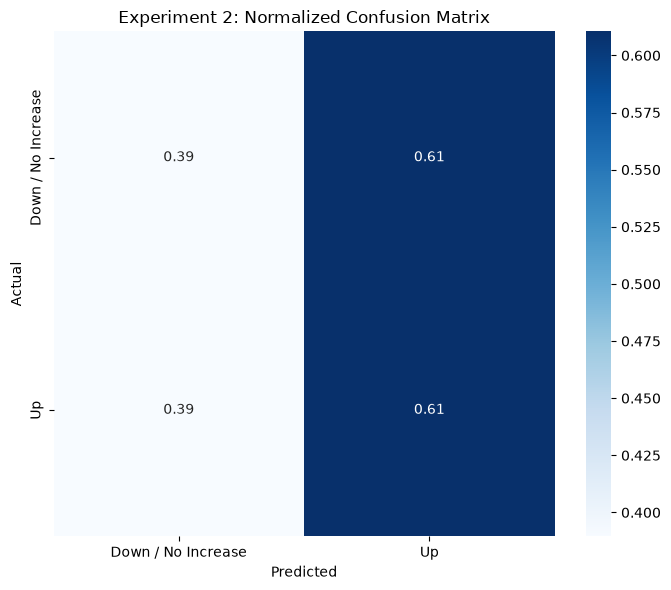

In [92]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Experiment 2: Normalized Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()

plt.savefig(
    str(MODELING_DIR / "experiment_2" / "normalized_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Classification Report

In [93]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="next_day_up",
    predictionCol="prediction"
)

accuracy_2 = evaluator.evaluate(
    predictions_2,
    {evaluator.metricName: "accuracy"}
)

weighted_precision_2 = evaluator.evaluate(
    predictions_2,
    {evaluator.metricName: "weightedPrecision"}
)

weighted_recall_2 = evaluator.evaluate(
    predictions_2,
    {evaluator.metricName: "weightedRecall"}
)

f1_2 = evaluator.evaluate(
    predictions_2,
    {evaluator.metricName: "f1"}
)

print(f"Accuracy:           {accuracy_2:.4f}")
print(f"Weighted Precision: {weighted_precision_2:.4f}")
print(f"Weighted Recall:    {weighted_recall_2:.4f}")
print(f"F1 Score:           {f1_2:.4f}")

Accuracy:           0.5069
Weighted Precision: 0.5019
Weighted Recall:    0.5069
F1 Score:           0.5014


Saving classification report.

In [94]:
classification_report_2 = spark.createDataFrame([
    ("Experiment 2", "Accuracy", accuracy_2),
    ("Experiment 2", "Weighted Precision", weighted_precision_2),
    ("Experiment 2", "Weighted Recall", weighted_recall_2),
    ("Experiment 2", "F1 Score", f1_2)
], ["experiment", "metric", "value"])

temp_dir = MODELING_DIR / "experiment_2" / "_classification_report_temp"
final_file = MODELING_DIR / "experiment_2" / "classification_report.csv"

(
    classification_report_2
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

# Experiment 3 - Tuned Gradient Boosted Tree Model

The third experiment uses a tuned GBT classifier with the purpose-built set of engineered financial features from the Gold layer.

## Feature Selection

In [95]:
# same features as Experiment 1 and 2
experiment_3_features = [
    "daily_return",
    "log_return",
    "price_change",
    "ma_5",
    "ma_20",
    "ma_50",
    "price_vs_ma5",
    "price_vs_ma20",
    "price_vs_ma50",
    "volatility_5",
    "volatility_20",
    "volatility_50",
    "avg_volume_20",
    "momentum_20"
]

target_col = "next_day_up"

experiment_3_df = gold_df.select(
    "ticker",
    "Date",
    *experiment_3_features,
    target_col
)

experiment_3_df.printSchema()

print(f"Rows: {experiment_3_df.count():,}")
print(f"Features: {len(experiment_3_features)}")

root
 |-- ticker: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- daily_return: double (nullable = true)
 |-- log_return: double (nullable = true)
 |-- price_change: double (nullable = true)
 |-- ma_5: double (nullable = true)
 |-- ma_20: double (nullable = true)
 |-- ma_50: double (nullable = true)
 |-- price_vs_ma5: double (nullable = true)
 |-- price_vs_ma20: double (nullable = true)
 |-- price_vs_ma50: double (nullable = true)
 |-- volatility_5: double (nullable = true)
 |-- volatility_20: double (nullable = true)
 |-- volatility_50: double (nullable = true)
 |-- avg_volume_20: double (nullable = true)
 |-- momentum_20: double (nullable = true)
 |-- next_day_up: integer (nullable = true)

Rows: 97,068
Features: 14


## Train/Test Split

In [96]:
dates = (
    experiment_3_df
    .select("Date")
    .distinct()
    .orderBy("Date")
    .collect()
)

split_date = dates[int(len(dates) * 0.8)]["Date"]

print(f"Training data through: {split_date}")

Training data through: 2022-09-06


In [97]:
train_3_df = experiment_3_df.filter(
    F.col("Date") < split_date
)

test_3_df = experiment_3_df.filter(
    F.col("Date") >= split_date
)

print(f"Training rows: {train_3_df.count():,}")
train_3_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

print(f"Test rows:     {test_3_df.count():,}")
test_3_df.selectExpr(
    "min(Date) as start_date",
    "max(Date) as end_date"
).show()

Training rows: 77,028
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2006-10-03|2022-09-02|
+----------+----------+

Test rows:     20,040
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2022-09-06|2026-09-02|
+----------+----------+



## Validation Split

The training data is further divided into training and validation sets to support hyperparameter tuning.  The validation set is used during the grid search to compare model configurations and the test set remains held out for final evaluation.

In [98]:
validation_split_date = (
    train_3_df
    .select("Date")
    .orderBy("Date")
    .limit(
        int(train_3_df.select("Date").count() * 0.8)
    )
    .agg({"Date": "max"})
    .collect()[0][0]
)

train_3_fit_df = train_3_df.filter(
    F.col("Date") <= validation_split_date
)

validation_3_df = train_3_df.filter(
    F.col("Date") > validation_split_date
)

## Model Pipeline

In [99]:
assembler_3 = VectorAssembler(
    inputCols=experiment_3_features,
    outputCol="features"
)

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="next_day_up",
    seed=SEED
)

gbt_pipeline_3 = Pipeline(
    stages=[
        assembler_3,
        gbt
    ]
)

## Define Param Grid

The parameter grid defines the combinations of hyperparameter values to be evaluated during model tuning.

In [100]:
param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5, 7])
    .addGrid(gbt.maxIter, [25, 50, 100])
    .addGrid(gbt.stepSize, [0.05, 0.1, 0.2])
    .build()
)

print(f"Parameter combinations: {len(param_grid)}")

Parameter combinations: 27


## Define Evaluator

The evaluator defines the performance metric used to compare model configurations during the parameter search.  For this experiment, F1-score is used to evaluate performance.

In [101]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="next_day_up",
    predictionCol="prediction",
    metricName="f1"
)

## Best Parameter Search

The parameter search evaluates the defined parameter combinations and identifies the configuration that produces the strongest performance according to the selected evaluation metric.

In [102]:
results = []

for params in param_grid:

    model = gbt_pipeline_3.fit(
        train_3_fit_df,
        params
    )

    validation_predictions = model.transform(
        validation_3_df
    )

    f1 = f1_evaluator.evaluate(
        validation_predictions
    )

    results.append(
        (params, f1)
    )

In [103]:
best_params, best_validation_f1 = builtins.max(
    results,
    key=lambda x: x[1]
)

print(f"Best validation F1: {best_validation_f1:.4f}")
print(best_params)

Best validation F1: 0.5132
{Param(parent='GBTClassifier_d6e44f494ef2', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes. Must be in range [0, 30].'): 3, Param(parent='GBTClassifier_d6e44f494ef2', name='maxIter', doc='max number of iterations (>= 0).'): 25, Param(parent='GBTClassifier_d6e44f494ef2', name='stepSize', doc='Step size (a.k.a. learning rate) in interval (0, 1] for shrinking the contribution of each estimator.'): 0.1}


## Best Model Evaluation

The best performing model configuration is evaluated on the test data to assess its classification performance using the same evaluation metrics used in Experiments 1 and 2.

In [104]:
gbt_model_3 = gbt_pipeline_3.fit(
    train_3_df,
    best_params
)

In [105]:
gbt_stage_3 = gbt_model_3.stages[-1]

In [106]:
print(f"Best maxDepth: {gbt_stage_3.getMaxDepth()}")
print(f"Best maxIter:  {gbt_stage_3.getMaxIter()}")
print(f"Best stepSize: {gbt_stage_3.getStepSize()}")

Best maxDepth: 3
Best maxIter:  25
Best stepSize: 0.1


In [107]:
predictions_3 = gbt_model_3.transform(test_3_df)

#### Prediction Probabilities

In [108]:
predictions_output_3 = predictions_3.select(
    "ticker",
    "Date",
    "next_day_up",
    "prediction",
    "probability"
)
predictions_output_3.show(10)

+------+----------+-----------+----------+--------------------+
|ticker|      Date|next_day_up|prediction|         probability|
+------+----------+-----------+----------+--------------------+
|  NVDA|2022-09-06|          1|       1.0|[0.46037214089483...|
|  NVDA|2022-09-07|          1|       0.0|[0.56850750598236...|
|  NVDA|2022-09-08|          1|       0.0|[0.51040930753072...|
|  NVDA|2022-09-09|          1|       1.0|[0.44172749252615...|
|  NVDA|2022-09-12|          0|       1.0|[0.45538952085660...|
|  NVDA|2022-09-13|          0|       1.0|[0.45189162579798...|
|  NVDA|2022-09-14|          0|       0.0|[0.54281156932877...|
|  NVDA|2022-09-15|          1|       1.0|[0.46037214089483...|
|  NVDA|2022-09-16|          1|       0.0|[0.58305556548348...|
|  NVDA|2022-09-19|          0|       1.0|[0.47603965501400...|
+------+----------+-----------+----------+--------------------+
only showing top 10 rows


Saving predictions and probabilities.

In [109]:
temp_dir = MODELING_DIR / "experiment_3" / "_predictions_temp"
final_file = MODELING_DIR / "experiment_3" / "predictions.csv"

(
    predictions_output_3
    .withColumn("probability", F.col("probability").cast("string"))
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Probability Summary

In [110]:
probability_summary_3 = predictions_3.select(
    F.round(F.min(vector_to_array("probability")[1]), 4).alias("Min"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.25
        ), 4
    ).alias("25th"),
    F.round(
        F.avg(vector_to_array("probability")[1]), 4
    ).alias("Mean"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.50
        ), 4
    ).alias("Median"),
    F.round(
        F.percentile_approx(
            vector_to_array("probability")[1], 0.75
        ), 4
    ).alias("75th"),
    F.round(
        F.max(vector_to_array("probability")[1]), 4
    ).alias("Max")
)

probability_summary_3.show()

+------+------+------+------+------+------+
|   Min|  25th|  Mean|Median|  75th|   Max|
+------+------+------+------+------+------+
|0.3266|0.4972|0.5096|0.5087|0.5254|0.6477|
+------+------+------+------+------+------+



Saving probability summary.

In [111]:
temp_dir = MODELING_DIR / "experiment_3" / "_probability_summary_temp"
final_file = MODELING_DIR / "experiment_3" / "probability_summary.csv"

(
    probability_summary_3
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Normalized Confusion Matrix

In [114]:
confusion_counts = (
    predictions_3
    .groupBy("next_day_up", "prediction")
    .count()
)

row_totals = (
    confusion_counts
    .groupBy("next_day_up")
    .agg(F.sum("count").alias("actual_total"))
)

confusion_normalized = (
    confusion_counts
    .join(row_totals, on="next_day_up")
    .withColumn(
        "proportion",
        F.col("count") / F.col("actual_total")
    )
    .orderBy("next_day_up", "prediction")
)

confusion_normalized.show()

+-----------+----------+-----+------------+-------------------+
|next_day_up|prediction|count|actual_total|         proportion|
+-----------+----------+-----+------------+-------------------+
|          0|       0.0| 2860|        9364|0.30542503203759075|
|          0|       1.0| 6504|        9364| 0.6945749679624093|
|          1|       0.0| 3318|       10676| 0.3107905582615212|
|          1|       1.0| 7358|       10676| 0.6892094417384789|
+-----------+----------+-----+------------+-------------------+



Saving normalized confusion matrix.

In [115]:
temp_dir = MODELING_DIR / "experiment_3" / "_confusion_matrix_temp"
final_file = MODELING_DIR / "experiment_3" / "confusion_matrix.csv"

(
    confusion_normalized
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

### Confusion Matrix Heatmap

In [116]:
cm_df = (
    confusion_counts
    .toPandas()
    .pivot(
        index="next_day_up",
        columns="prediction",
        values="count"
    )
    .fillna(0)
)

cm_df.index = ["Down / No Increase", "Up"]
cm_df.columns = ["Down / No Increase", "Up"]

cm_norm = cm_df.div(
    cm_df.sum(axis=1),
    axis=0
)

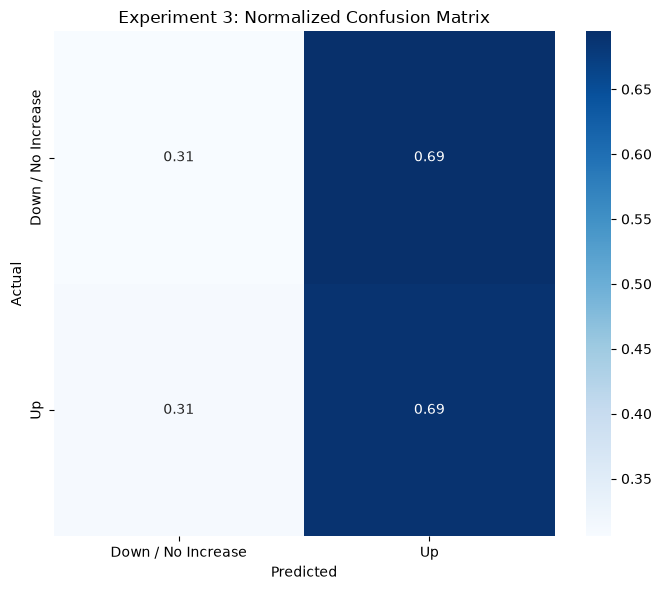

In [117]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Experiment 3: Normalized Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()

plt.savefig(
    str(MODELING_DIR / "experiment_3" / "normalized_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Classification Report

In [118]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="next_day_up",
    predictionCol="prediction"
)

accuracy_3 = evaluator.evaluate(
    predictions_3,
    {evaluator.metricName: "accuracy"}
)

weighted_precision_3 = evaluator.evaluate(
    predictions_3,
    {evaluator.metricName: "weightedPrecision"}
)

weighted_recall_3 = evaluator.evaluate(
    predictions_3,
    {evaluator.metricName: "weightedRecall"}
)

f1_3 = evaluator.evaluate(
    predictions_3,
    {evaluator.metricName: "f1"}
)

print(f"Accuracy:           {accuracy_3:.4f}")
print(f"Weighted Precision: {weighted_precision_3:.4f}")
print(f"Weighted Recall:    {weighted_recall_3:.4f}")
print(f"F1 Score:           {f1_3:.4f}")

Accuracy:           0.5099
Weighted Precision: 0.4991
Weighted Recall:    0.5099
F1 Score:           0.4915


Saving classification report.

In [119]:
classification_report_3 = spark.createDataFrame([
    ("Experiment 3", "Accuracy", accuracy_3),
    ("Experiment 3", "Weighted Precision", weighted_precision_3),
    ("Experiment 3", "Weighted Recall", weighted_recall_3),
    ("Experiment 3", "F1 Score", f1_3)
], ["experiment", "metric", "value"])

temp_dir = MODELING_DIR / "experiment_3" / "_classification_report_temp"
final_file = MODELING_DIR / "experiment_3" / "classification_report.csv"

(
    classification_report_3
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

---

# Experiment Summary

This section summarizes and compares the results across the experiments conducted for the analysis presented in the report.

## Classification Performance Comparison

This comparison examines overall model performance across experiments using accuracy, precision, recall and F1 score.

In [120]:
# combining classification reports for comparison
classification_comparison = (
    classification_report_1
    .union(classification_report_2)
    .union(classification_report_3)
    .groupBy("metric")
    .pivot("experiment")
    .agg({"value": "first"})
    .orderBy("metric")
)

classification_comparison.show()

+------------------+-------------------+------------------+-------------------+
|            metric|       Experiment 1|      Experiment 2|       Experiment 3|
+------------------+-------------------+------------------+-------------------+
|          Accuracy| 0.5133233532934132| 0.506936127744511| 0.5098802395209581|
|          F1 Score|0.49398563985784427|0.5013594927167844| 0.4914631343386293|
|Weighted Precision|  0.502652484971176|0.5018525282409245|0.49909002575125405|
|   Weighted Recall| 0.5133233532934132| 0.506936127744511| 0.5098802395209581|
+------------------+-------------------+------------------+-------------------+



## Ticker-level Accuracy Comparison

This comparison examines model accuracy across individual securities to identify variation in performance between tickers and across experiments.

In [123]:
# aggregating predictions by ticker to compare results by experiment
ticker_accuracy_1 = (
    predictions_1
    .groupBy("ticker")
    .agg(
        F.avg(
            (F.col("prediction") == F.col("next_day_up")).cast("double")
        ).alias("Experiment 1")
    )
)

ticker_accuracy_2 = (
    predictions_2
    .groupBy("ticker")
    .agg(
        F.avg(
            (F.col("prediction") == F.col("next_day_up")).cast("double")
        ).alias("Experiment 2")
    )
)

ticker_accuracy_3 = (
    predictions_3
    .groupBy("ticker")
    .agg(
        F.avg(
            (F.col("prediction") == F.col("next_day_up")).cast("double")
        ).alias("Experiment 3")
    )
)

In [124]:
ticker_accuracy_comparison = (
    ticker_accuracy_1
    .join(ticker_accuracy_2, "ticker")
    .join(ticker_accuracy_3, "ticker")
    .orderBy("ticker")
)

ticker_accuracy_comparison.show()

+------+-------------------+-------------------+-------------------+
|ticker|       Experiment 1|       Experiment 2|       Experiment 3|
+------+-------------------+-------------------+-------------------+
|  AAPL| 0.4940119760479042| 0.5239520958083832| 0.5089820359281437|
|  AMZN| 0.5239520958083832| 0.5089820359281437| 0.5149700598802395|
|  AVGO| 0.5209580838323353| 0.5089820359281437| 0.5039920159680639|
|   BAC| 0.5199600798403193|0.49700598802395207|0.49600798403193613|
| BRK-B| 0.4940119760479042|0.49600798403193613| 0.5179640718562875|
|   CAT|0.48602794411177647| 0.5259481037924152| 0.5449101796407185|
|    GE| 0.5269461077844312| 0.4870259481037924| 0.5289421157684631|
| GOOGL| 0.5289421157684631| 0.5039920159680639| 0.5109780439121756|
|   JNJ| 0.5119760479041916| 0.5129740518962076| 0.5149700598802395|
|   JPM| 0.5379241516966068| 0.5169660678642715| 0.5199600798403193|
|   LLY| 0.4940119760479042|0.49500998003992014| 0.5159680638722555|
|  META|0.49700598802395207|0.4970

## Prediction Probability Summary Comparison

This comparison examines the distribution of predicted probabilities across experiments using summary statistics and quartiles.

In [125]:
# defining probability summaries with experiment labels
probability_summary_1 = probability_summary_1.withColumn(
    "Experiment",
    F.lit("Logistic Regression - Full Gold")
)

probability_summary_2 = probability_summary_2.withColumn(
    "Experiment",
    F.lit("GBT - Full Gold")
)

probability_summary_3 = probability_summary_3.withColumn(
    "Experiment",
    F.lit("Tuned GBT")
)

In [126]:
# combining summaries for comparison
probability_comparison = (
    probability_summary_1
    .unionByName(probability_summary_2)
    .unionByName(probability_summary_3)
    .select(
        "Experiment",
        "Min",
        "25th",
        "Mean",
        "Median",
        "75th",
        "Max"
    )
)

probability_comparison.show()

+--------------------+------+------+------+------+------+------+
|          Experiment|   Min|  25th|  Mean|Median|  75th|   Max|
+--------------------+------+------+------+------+------+------+
|Logistic Regressi...|0.2466|0.4966|0.5057| 0.509|0.5186|0.7126|
|     GBT - Full Gold|0.1279|0.4821|0.5087|0.5112|0.5373|0.9161|
|           Tuned GBT|0.3266|0.4972|0.5096|0.5087|0.5254|0.6477|
+--------------------+------+------+------+------+------+------+



Saving probability comparison summary.

In [127]:
temp_dir = MODELING_DIR / "experiment_2" / "_probability_comparison_summary_temp"
final_file = MODELING_DIR / "experiment_2" / "probability_comparison_summary.csv"

(
    probability_comparison
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(str(temp_dir))
)

csv_file = next(temp_dir.glob("part-*.csv"))

shutil.move(
    str(csv_file),
    str(final_file)
)

shutil.rmtree(temp_dir)

## Prediction Probability Distribution Comparison

This comparison provides a visual comparison of predicted probability distributions across experiments and highlights differences in the range and concentration of model confidence.

In [128]:
# converting spark predictions data to pandas for plotting
prob_1 = predictions_1.select(
    vector_to_array("probability")[1].alias("prob_up")
).toPandas()

prob_2 = predictions_2.select(
    vector_to_array("probability")[1].alias("prob_up")
).toPandas()

prob_3 = predictions_3.select(
    vector_to_array("probability")[1].alias("prob_up")
).toPandas()

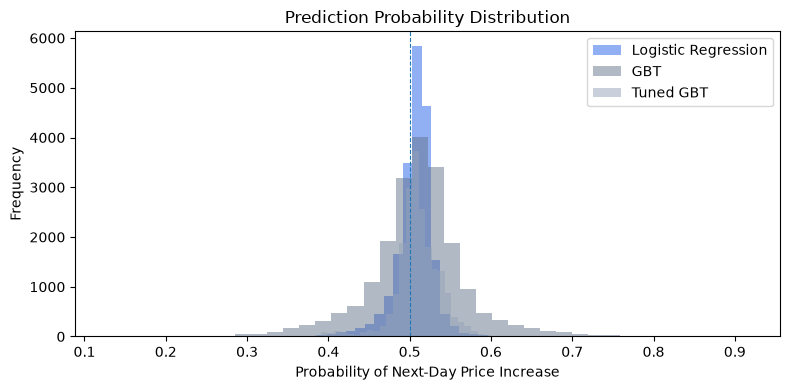

<Figure size 640x480 with 0 Axes>

In [129]:
plt.figure(figsize=(8, 4))

for prob, color, label in zip(
    [prob_1, prob_2, prob_3],
    colors,
    ["Logistic Regression", "GBT", "Tuned GBT"]
):
    plt.hist(
        prob["prob_up"],
        bins=40,
        alpha=0.5,
        label=label,
        color=color
    )

plt.axvline(
    0.5,
    linestyle="--",
    linewidth=0.8
)

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Next-Day Price Increase")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "prediction_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.savefig(
    FIG_DIR / "prediction_probability_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()